In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath

In [2]:
def nice_boundary_path_for_maps(lon,lat):
    
    Path = mpath.Path
    path_data = [(Path.MOVETO, (lon.min(), lat.min()))]

    for lo in lon:
        path_data.append((Path.LINETO, (lo, lat.min())))
    
    path_data.append((Path.LINETO, (lon.max(), lat.max())))

    for lo in np.flip(lon):
        path_data.append((Path.LINETO, (lo, lat.max())))
    
    path_data.append((Path.CLOSEPOLY, (lon.min(), lat.min())))
    codes, verts = zip(*path_data)
    path = mpath.Path(verts, codes)

    return path

In [3]:
path = '../data/WAVEGUISE_ERA5_MSLP_TTC_20240502T06.nc'
ds = xr.open_dataset(path)

In [4]:
path = '../data/WAVEGUISE_ERA5_vort_z_20240502T06_850hPa.nc'
ds2 = xr.open_dataset(path)

In [5]:
path = '../data/ERA5_precipitation_20240502T06.nc'
tp_ds = xr.open_dataset(path)

In [9]:
path = '../data/ERA5_ds2.nc'
cape_ds = xr.open_dataset(path)
path = '../data/ERA5_ds1.nc'
tp_ds = xr.open_dataset(path)

Text(0.5, 1.0, '2 May 2024 06UTC')

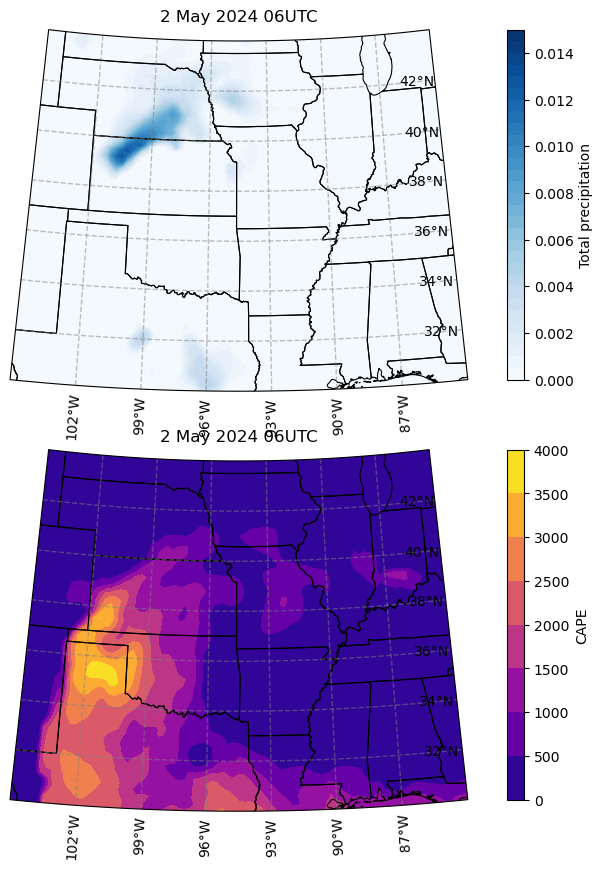

In [11]:
lon = cape_ds['longitude']
lat = cape_ds['latitude']

# Robust min/max for numpy or xarray
lon_min = float(np.nanmin(lon))
lon_max = float(np.nanmax(lon))
lat_min = float(np.nanmin(lat))
lat_max = float(np.nanmax(lat))

clon, clat = (lon_min+lon_max)/2, (lat_min+lat_max)/2

# Boundary + extent
xs = np.linspace(lon_min, lon_max, 80)
ys = np.linspace(lat_min, lat_max, 80)
path = nice_boundary_path_for_maps(xs, ys)

projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)

fig=plt.figure(figsize=(10,10))
ax1=fig.add_subplot(211,projection=projStr)
plot_tp = ax1.contourf(tp_ds['longitude'],tp_ds['latitude'],tp_ds['tp'].isel(valid_time=0),levels=np.linspace(0,0.015,31),transform=ccrs.PlateCarree(),cmap='Blues')
cbar = fig.colorbar(plot_tp,label="Total precipitation")
ax1.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")
ax1.set_boundary(path, transform=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, linewidth=1, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = True  # usually cleaner than True
gl.bottom_labels = True
gl.left_labels = False
ax1.set_title('2 May 2024 06UTC')


ax2=fig.add_subplot(212,projection=projStr)
plot_cape = ax2.contourf(cape_ds['longitude'],cape_ds['latitude'],cape_ds['cape'].isel(valid_time=0),transform=ccrs.PlateCarree(),cmap='plasma')
cbar = fig.colorbar(plot_cape,label="CAPE")
ax2.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")
ax2.set_boundary(path, transform=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
gl = ax2.gridlines(draw_labels=True, linewidth=1, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = True  # usually cleaner than True
gl.bottom_labels = True
gl.left_labels = False
ax2.set_title('2 May 2024 06UTC')

#plt.savefig('./figures/WAVEGUISE_ERA5_fields.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

KeyError: "No variable named 'tp'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'cape']"

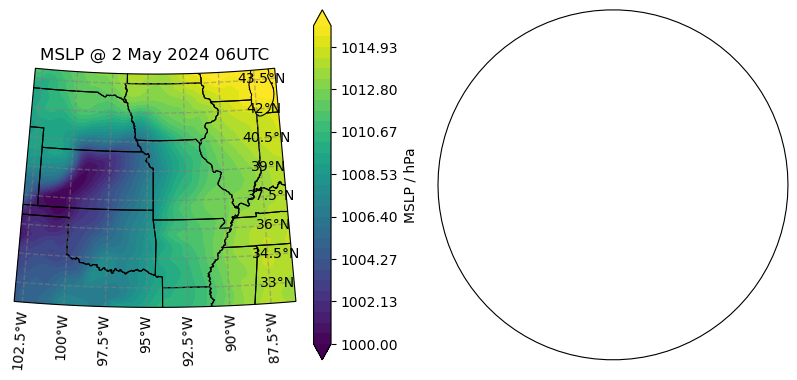

In [21]:
lon = ds['longitude']
lat = ds['latitude']

# Robust min/max for numpy or xarray
lon_min = float(np.nanmin(lon))
lon_max = float(np.nanmax(lon))
lat_min = float(np.nanmin(lat))
lat_max = float(np.nanmax(lat))

clon, clat = (lon_min+lon_max)/2, (lat_min+lat_max)/2

# Boundary + extent
xs = np.linspace(lon_min, lon_max, 80)
ys = np.linspace(lat_min, lat_max, 80)
path = nice_boundary_path_for_maps(xs, ys)

projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)

fig=plt.figure(figsize=(10,10))
ax1=fig.add_subplot(221,projection=projStr)
plot_msl = ax1.contourf(ds['longitude'],ds['latitude'],ds['msl'].isel(valid_time=0)*1e-2,transform=ccrs.PlateCarree(),
                      levels=np.linspace(100_0,101_6,31),extend='both')
cbar = fig.colorbar(plot_msl,label="MSLP / hPa")
ax1.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")
ax1.set_boundary(path, transform=ccrs.PlateCarree())
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, linewidth=1, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = True  # usually cleaner than True
gl.bottom_labels = True
gl.left_labels = False
ax1.set_title('MSLP @ 2 May 2024 06UTC')


ax2=fig.add_subplot(222,projection=projStr)
plot_tp = ax2.contourf(ds3['longitude'],ds3['latitude'],ds3['tp'].isel(valid_time=0),transform=ccrs.PlateCarree(),cmap='Blues')
cbar = fig.colorbar(plot_tp,label="TP")
ax2.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")
ax2.set_boundary(path, transform=ccrs.PlateCarree())
ax2.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
gl = ax2.gridlines(draw_labels=True, linewidth=1, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = True  # usually cleaner than True
gl.bottom_labels = True
gl.left_labels = False
ax2.set_title('TP @ 2 May 2024 06UTC')


ax3=fig.add_subplot(223,projection=projStr)
plot_vo = ax3.contourf(ds2['longitude'],ds2['latitude'],ds2['vo'].isel(valid_time=0,pressure_level=0),transform=ccrs.PlateCarree(),
                      levels=np.linspace(-1e-4,1e-4,31),cmap='RdBu_r',extend='both')
cbar = fig.colorbar(plot_vo,label="rel. vorticity / $s^{-1}$")
ax3.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")
ax3.set_boundary(path, transform=ccrs.PlateCarree())
ax3.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
gl = ax3.gridlines(draw_labels=True, linewidth=1, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = True  # usually cleaner than True
gl.bottom_labels = True
gl.left_labels = False
ax3.set_title('rel. vorticity @850hPa @ 2 May 2024 06UTC')


ax4=fig.add_subplot(224,projection=projStr)
plot_z = ax4.contourf(ds2['longitude'],ds2['latitude'],ds2['z'].isel(valid_time=0,pressure_level=0),transform=ccrs.PlateCarree(),
                      levels=np.linspace(np.min(ds2['z']),np.max(ds2['z']),31),cmap='plasma')
cbar = fig.colorbar(plot_z,label="geopotential / m")
ax4.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")
ax4.set_boundary(path, transform=ccrs.PlateCarree())
ax4.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
gl = ax4.gridlines(draw_labels=True, linewidth=1, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = True  # usually cleaner than True
gl.bottom_labels = True
gl.left_labels = False
ax4.set_title('Geopotential @850hPa @ 2 May 2024 06UTC')

#plt.savefig('./figures/WAVEGUISE_ERA5_fields.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [14]:
path = '../data/ERA5_ds1.nc'
ds3 = xr.open_dataset(path)

In [19]:
plt.contourf(ds3['longitude'],ds3['latitude'],ds3['tp'].isel(valid_time=0))

KeyError: "No variable named 'tp'. Variables on the dataset include ['number', 'valid_time', 'latitude', 'longitude', 'expver', 'cape']"

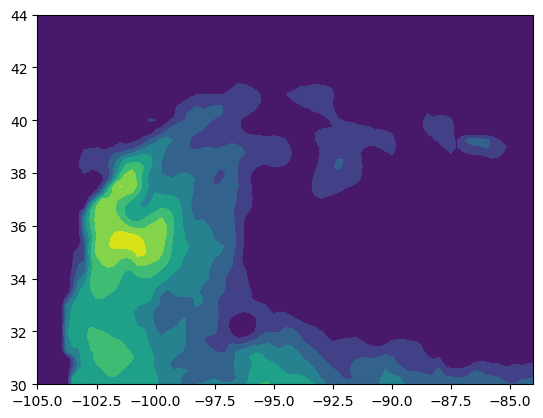

In [20]:
plt.contourf(ds3['longitude'],ds3['latitude'],ds3['cape'].isel(valid_time=0))